<a href="https://colab.research.google.com/github/Pragzz05/Heart-Disease-Prediction-using-Multiple-Machine-Learning-Algorithms/blob/main/models/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

**Step 2: Load Dataset**

In [ ]:
df = pd.read_csv('/content/HeartDiseaseTrain-Test.csv')  # upload your dataset

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


**Step 3: Preprocessing**

In [ ]:
# Clean and prepare the dataset (handling missing values, etc.)

print(df.isnull().sum())


age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


**Step 4: Feature Selection and Data Splitting**

In [ ]:

# Separate features and target variable, then split into training and testing sets.

X = df.drop('target', axis=1)
y = df['target']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Step 5: Feature Scaling**

In [ ]:
#Normalize the feature values for better performance.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 6: Model Training using Logistic Regression**

In [ ]:
#Train the model to learn patterns from the dataset.

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Step 7: Model Prediction on Test Data**

In [ ]:
# Use the trained model to make predictions on unseen data.

y_pred = model.predict(X_test)

**Step 8: Model Evaluation**

In [ ]:
# Evaluate the performance of the model.

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.7951219512195122

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.75      0.78       102
           1       0.77      0.84      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



**Step 9: Confusion Matrix Visualization**

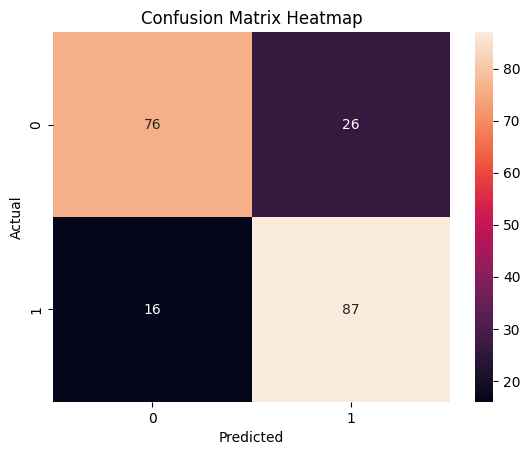

In [ ]:
# Visualize model performance using heatmap.

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

**Step 10: Learning Curve Analysis**

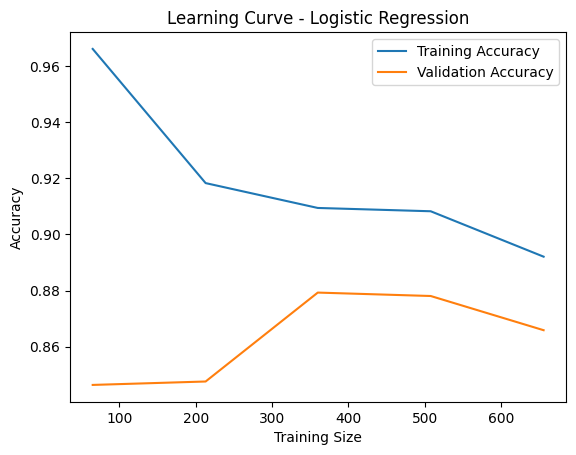

In [ ]:
# Analyze training and validation performance.

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.show()

**Step 11: Sample Prediction (New Patient)**

In [ ]:
# Predict heart disease for a new sample input.

sample_values = {
    'age': 52,
    'sex': 1,
    'chest_pain_type': 2,
    'resting_blood_pressure': 125,
    'cholestoral': 212,
    'fasting_blood_sugar': 0,
    'rest_ecg': 1,
    'Max_heart_rate': 168,
    'exercise_induced_angina': 0,
    'oldpeak': 1.0,
    'slope': 2,
    'vessels_colored_by_flourosopy': 2,
    'thalassemia': 3
}

sample_df = pd.DataFrame([sample_values])

# Encode + align columns
sample_df = pd.get_dummies(sample_df, drop_first=True)
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

# Scale
sample_scaled = scaler.transform(sample_df)

# Predict
prediction = model.predict(sample_scaled)

if prediction[0] == 1:
    print("The person is likely to have Heart Disease")
else:
    print("The person is NOT likely to have Heart Disease")

The person is likely to have Heart Disease
